# 快速验证
这个demo主要提供部分样板代码，方便快速验证新知识点

## 修改历史
验证涉及的新知识点记录在这里，作为备忘

- StateSchema的每一个属性都是channel，通道会依据metadata中指定的归约器进行状态更新
- channel的默认（即不指定归约器）行为是 覆盖 ，即新值覆盖旧值
- 使用operator.add作为归约器时，如果是list，会把所有并行节点的计算结果追加到list末尾，如果是数字类型，那么会依次对每个节点的返回值做add
- Annotated是py的预置类型，为已有类型添加元数据，langgraph用它来指定归约器
- 自定义reducer可以定制符合业务规则的归约逻辑；尽量保持幂等性；自定义reducer可以根据业务需要实现不同的合并策略；同样可以
- list(set(list_a, list_b))可以实现去重合并
- RemoveMessage是langchain_core暴露的MessagesState操作函数，用于删除指定id的消息


### py知识点
- list[-n:] : 保留最新的n个元素,如果不带:，表示读取从后往前的第n个元素
- {**args1, **args2}: 深度合并两个字典，同名元素会覆盖



## Error

Error:  InvalidUpdateError occurred: At key 'foo': Can receive only one value per step. Use an Annotated key to handle multiple values.
Reason: 使用默认归约器的覆盖规则，但是出现节点并行更新，导致更新冲突，不知道该保留哪一个

In [111]:
# 创建glm4.7的客户端实例，一般不用改
from langchain_openai import ChatOpenAI


glm_client = ChatOpenAI(
    model="glm-4.7",
    api_key="d1de7475090740ebb6c887167a6a8b98.2WUSfYbmgQwYLKF4",
    base_url="https://open.bigmodel.cn/api/paas/v4/",  # 智谱OpenAI兼容地址，末尾斜杠不能丢
)



In [112]:
# 主要修改部分： 这部分构建图，可以按需修改图的状态schema及节点和图结构
import operator
from typing import Annotated, TypedDict

from langgraph.graph import END, START, StateGraph


# # add不能处理None，定制归约器来兼容None的场景
# def cust_reducer(old: list | None, new: list | None) -> list:
#     if not old:
#         old = []
#     if not new:
#         new = []

#     return list(set(old + new))


def keep_last_n( n: int) -> list:
    def reducer(old:list, new:list)->list:
        res = old + new;
        if len(res) <= n:
                return res
        return res[-n:]
    return reducer


class State(TypedDict):
    foo: Annotated[list[int], keep_last_n(1)]


def node_1(state: State):
    print(f"node value is {state['foo']}")
    return {"foo": [2]}


def node_2(state: State):
    return {"foo": [2]}


graph = StateGraph(State)

graph.add_node("node_1", node_1)
graph.add_node("node_2", node_2)

graph.add_edge(START, "node_1")
graph.add_edge(START, "node_2")
graph.add_edge("node_1", END)
graph.add_edge("node_2", END)

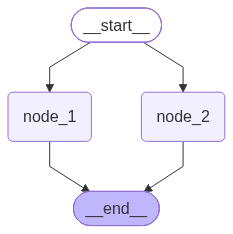

In [113]:
# 基本不用改，构建运行时并打印图结构
from IPython.display import display, Image

app = graph.compile()
display(Image(app.get_graph().draw_mermaid_png()))

In [114]:
# 测试图并打印结果
from langchain_core.messages import HumanMessage

# 修改这行代码修改输入消息
# message = HumanMessage(content="今天天气如何")
message = {"foo":[1]}
res = app.invoke({"foo":[1]})

print(res)
# for msg in res["messages"]:
#     msg.model_dump_json(indent = 2)

node value is [1]
{'foo': [2]}
